# **Semestrální práce - Analýza finančního datasetu**
### Jan Cihlář

# DATA HANDLING

In [2]:
import pandas as pd
import sqlite3
import requests
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

In [3]:
#Global variables
path = 'CS bank data.csv'
url = "https://api.exchangerate-api.com/v4/latest/EUR"

****API FX RATE****

In [4]:
def get_fx_rate(url, currency = "CZK"):
    try:
        response = requests.get(url)
        response.raise_for_status()
        if response.status_code == 200:
            print("API request successful")
            data = response.json()
            fx_rate = data["rates"][currency]
    except Exception as e:
        print(f"Error: {e}")
    return fx_rate

****FILE READ****

In [5]:
#Načtení datasetu
def read_data(path):
    try:
        df = pd.read_csv(path, encoding="utf-16")
        print("Data successfully read")
        return df
    except FileNotFoundError:
        print(f"File not found: {path}")
        return None
    except Exception as e:
        print(f"Other error: {e}")
        return None
 

****DATABASE LOADING****

In [6]:
def get_connection():
    conn = sqlite3.connect('bank.db')
    return conn

****LOAD BRONZE DATA****

In [7]:
def load_data_database(df):
    conn = get_connection()
    df.to_sql('bank', conn, index=False, if_exists="replace")
    conn.close()
    print("Data successfully loaded to database")

****SILVER LAYER****

In [8]:
#Load silver vrstvy
def prepare_silver_layer(conn):
    tables = {
        "customers": pd.read_sql(
            "SELECT CustomerID, Name, Address, Phone, Phone_2 FROM bank", conn
        ),
        "accounts": pd.read_sql(
            "SELECT AccountID, CustomerID, AccountType, Balance, APR, DateOpened FROM bank", conn
        ),
        "transactions": pd.read_sql(
            "SELECT TransactionID, AccountID, Date, Type, Amount, Fee FROM bank", conn
        ),
        "branches": pd.read_sql(
            "SELECT BranchID, BranchName, ManagerID FROM bank", conn
        ),
        "employees": pd.read_sql(
            "SELECT EmployeeID, Name, Position, BranchID, DateHired FROM bank", conn
        ),
    }
    print("Silver layer successfully created")
    conn.close()
    return tables

In [9]:
df = read_data(path)
conn = get_connection()
if df is not None:
    load_data_database(df)
silver_layer = prepare_silver_layer(conn)
conn.close()
fx_rate = get_fx_rate(url)

Data successfully read
Data successfully loaded to database
Silver layer successfully created
API request successful


# DATA TRANSFORMATION

In [10]:
#Data transformations for customers
customers = silver_layer['customers']

customers = customers.drop_duplicates(subset=["CustomerID"])
customers = customers.dropna(subset=["CustomerID"])
customers = customers.astype({"CustomerID":"int64"})
customers["Phone"] = customers["Phone"].str.replace(r"\D", "", regex=True).str.strip()
customers["Phone"] = pd.to_numeric(customers["Phone"], errors="coerce")
customers = customers.assign(phone_cleaned = customers["Phone"]
    .astype("string")
    .str.replace(r"\D", "", regex=True))
customers.loc[customers["phone_cleaned"].str.len() > 15, "phone_cleaned"] = "-"
customers = customers.drop(columns=["Phone", "Phone_2"])
customers = customers.rename(columns={"Name": "Customer_name", "phone_cleaned": "Phone"})



In [11]:
#Customer gold table checks
customers.info()
customers.nunique()
customers.isnull().sum()
customers[customers.duplicated()]

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     100 non-null    int64 
 1   Customer_name  100 non-null    object
 2   Address        100 non-null    object
 3   Phone          100 non-null    string
dtypes: int64(1), object(2), string(1)
memory usage: 3.9+ KB


,CustomerID,Customer_name,Address,Phone


In [12]:
#Data transformation for accounts
accounts = silver_layer['accounts']

accounts = accounts.dropna(subset=["AccountID"])
accounts = accounts.drop_duplicates(subset=["AccountID"], keep="first")
accounts[["Balance_amount", "Currency"]] = accounts["Balance"].str.split(" ", expand=True)
accounts = accounts.drop(columns="Balance")
accounts["APR"] = accounts["APR"].str.replace(",", ".", regex=False).astype("float64").round(2)
accounts["DateOpened"] = pd.to_datetime(accounts["DateOpened"]).dt.floor("D")
accounts = accounts.astype({"AccountID": "int64", "CustomerID": "int64", "APR": "float64", "Balance_amount": "float64", "Currency": "category"})


In [13]:
#Accounts gold table checks
accounts.info()
accounts.nunique()
accounts.isnull().sum()
accounts[accounts.duplicated()]

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 100 to 249
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   AccountID       150 non-null    int64         
 1   CustomerID      150 non-null    int64         
 2   AccountType     150 non-null    object        
 3   APR             150 non-null    float64       
 4   DateOpened      150 non-null    datetime64[ns]
 5   Balance_amount  150 non-null    float64       
 6   Currency        150 non-null    category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 8.5+ KB


,AccountID,CustomerID,AccountType,APR,DateOpened,Balance_amount,Currency


In [14]:
#Data transformations for transactions
transactions = silver_layer['transactions']

transactions = transactions.drop_duplicates(subset=["TransactionID"], keep="first")
transactions = transactions.dropna(subset=["TransactionID"])
transactions["Date"] = pd.to_datetime(transactions["Date"]).dt.floor("D")
transactions["Amount"] = transactions["Amount"].str.replace(",", ".", regex=False).astype("float64").round(2)
transactions = transactions.astype({"TransactionID": "int64", "AccountID": "int", "Type": "category", "Amount": "float64", "Fee": "int64"})

In [15]:
#transactions gold table checks
transactions.info()
transactions.nunique()
transactions.isnull().sum()
transactions[transactions.duplicated()]

<class 'pandas.core.frame.DataFrame'>
Index: 3076 entries, 250 to 3325
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  3076 non-null   int64         
 1   AccountID      3076 non-null   int64         
 2   Date           3076 non-null   datetime64[ns]
 3   Type           3076 non-null   category      
 4   Amount         3076 non-null   float64       
 5   Fee            3076 non-null   int64         
dtypes: category(1), datetime64[ns](1), float64(1), int64(3)
memory usage: 147.4 KB


,TransactionID,AccountID,Date,Type,Amount,Fee


In [16]:
#Data transformations for branches
branches = silver_layer['branches']

branches = branches.dropna(subset=["ManagerID"])
branches = branches.drop_duplicates(subset=["ManagerID"], keep="first").sort_values(by="BranchID")
branches = branches.astype({"BranchID": "int64", "ManagerID": "int64"})

In [17]:
#Data transformations for employees
employees = silver_layer['employees']
employees = employees.dropna(subset=["EmployeeID"]).copy()
employees["DateHired"] = pd.to_datetime(employees["DateHired"]).dt.floor("D")
employees = employees.astype({"EmployeeID": "int64", "BranchID": "int64"})

In [18]:
#Load to gold layer
tables_gold = {
    "customers": customers,
    "accounts": accounts,
    "transactions": transactions,
    "branches": branches,
    "employees": employees
}
conn = get_connection()
for table, table_name in tables_gold.items():
    print(f"---PRINTING TABLE {table}---")
    table_name.to_sql(table, conn, index=False, if_exists="replace")
    print(f"{table} PRINTED")

---PRINTING TABLE customers---
customers PRINTED
---PRINTING TABLE accounts---
accounts PRINTED
---PRINTING TABLE transactions---
transactions PRINTED
---PRINTING TABLE branches---
branches PRINTED
---PRINTING TABLE employees---
employees PRINTED


# DATA ANALYSIS

***BUSSINES Q.1 - an overview of available banking products and their current volume***

In [19]:
accounts["Balance_amount_czk"] = np.where(accounts["Currency"] == "CZK", accounts["Balance_amount"], accounts["Balance_amount"] * fx_rate)
accounts_banking_products = accounts.groupby("AccountType")["Balance_amount_czk"].sum().sort_values(ascending=False)
accounts_banking_products = accounts_banking_products.to_frame()
accounts_banking_products["portfolio_weight"] = accounts_banking_products / accounts_banking_products.sum()

In [20]:
accounts_banking_products

,Balance_amount_czk,portfolio_weight
AccountType,,
Loan,8.259839e+08,0.884682
Saving,1.053071e+08,0.112791
Current,2.359398e+06,0.002527


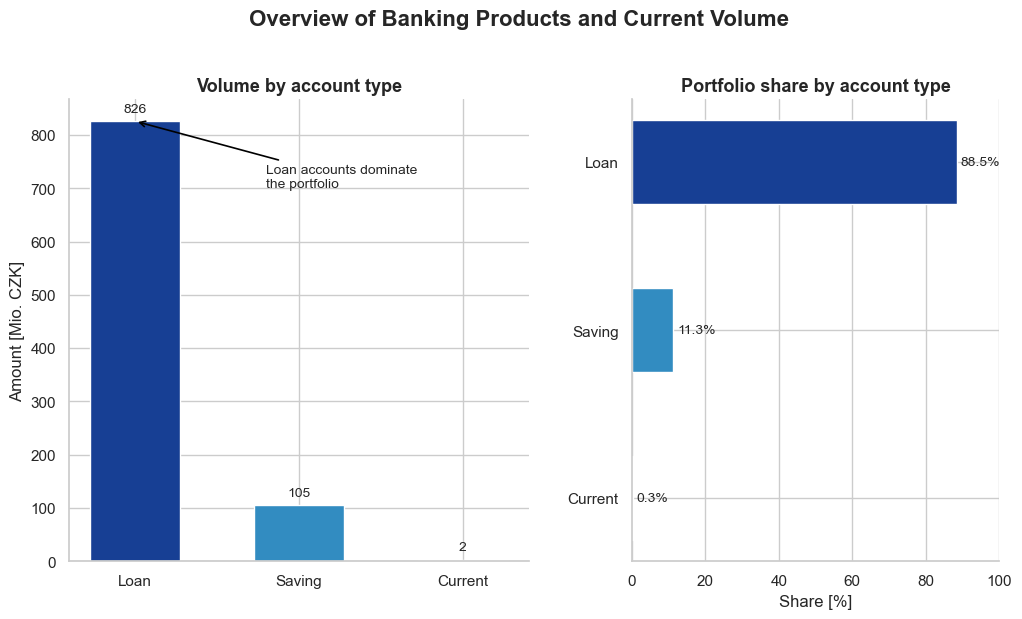

In [21]:
sns.set_theme(style="whitegrid")

df_plot = accounts_banking_products.copy()

df_plot["amount_mio"] = df_plot["Balance_amount_czk"] / 1000000
df_plot["portfolio_weight_pct"] = df_plot["portfolio_weight"].astype(float) * 100

df_plot = df_plot.sort_values("amount_mio", ascending=False)

colors = ["#173F94", "#328CC1", "#D9E6F2"]

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.25, 1], wspace=0.25)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

bars = ax1.bar(
    df_plot.index,
    df_plot["amount_mio"],
    color=colors,
    width=0.55
)

ax1.set_title("Volume by account type", fontsize=13, fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("Amount [Mio. CZK]")

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 12,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax1.annotate(
    "Loan accounts dominate\nthe portfolio",
    xy=(0, df_plot["amount_mio"].iloc[0]),
    xytext=(0.8, df_plot["amount_mio"].iloc[0] * 0.85),
    arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
    fontsize=10,
    ha="left",
)

ax2.barh(
    df_plot.index,
    df_plot["portfolio_weight_pct"],
    color=colors,
    height=0.5
)

ax2.set_title("Portfolio share by account type", fontsize=13, fontweight="bold")
ax2.set_xlabel("Share [%]")
ax2.set_ylabel("")
ax2.set_xlim(0, 100)
ax2.invert_yaxis()

for i, value in enumerate(df_plot["portfolio_weight_pct"]):
    ax2.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

fig.suptitle(
    "Overview of Banking Products and Current Volume",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.show()

***BUSSINES Q.2 - the count and volume of transactions per product***


In [22]:
transactions_count = transactions.merge(accounts, how="inner", on="AccountID")
transactions_count = (transactions_count.
                        groupby(["AccountType", "Type"], observed=False)
                        [["AccountType", "Type", "Amount"]]
                        .agg({"Type": "count", "Amount":"sum"}))
transactions_count = (transactions_count[transactions_count["Type"] > 0]
                      .rename(columns={"Type": "Transactions_count", "Amount": "Transactions_amount"}))
transactions_count.index.names = ["Account_type", "Transaction_type"]
transactions_count


Transactions_count  Transactions_amount
Account_type Transaction_type                                         
Current      Deposit                          463            671514.17
             Transfer                         455            667659.44
             Withdrawal                       442            665068.80
Saving       Bonus                             51             25500.00
             Deposit                         1665           7579870.68

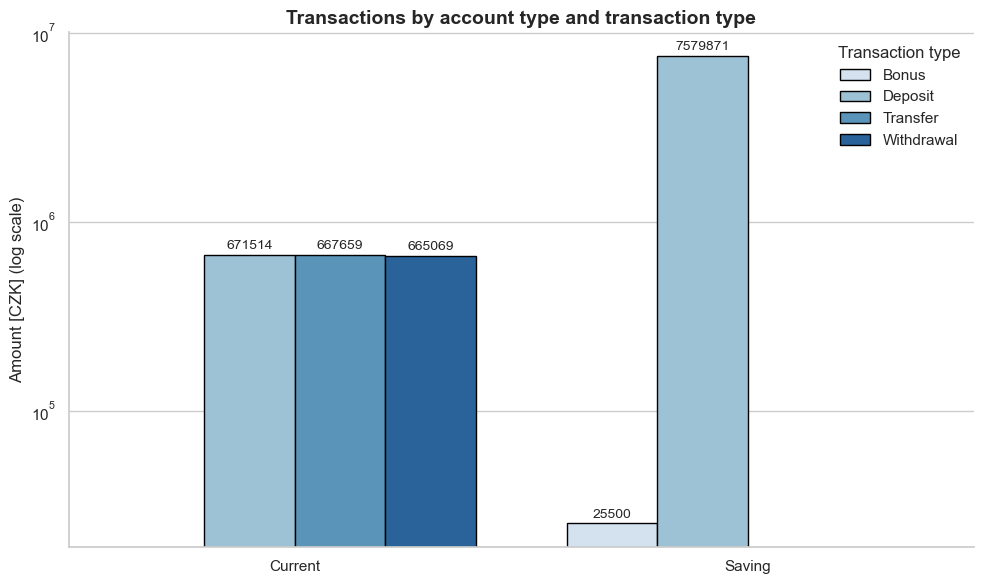

In [23]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x="Account_type",
    y="Transactions_amount",
    hue="Transaction_type",
    data=transactions_count,
    palette="Blues",
    edgecolor="black"
)

# log scale (necháme, ale upravíme label)
ax.set_yscale("log")

ax.set_xlabel("")
ax.set_ylabel("Amount [CZK] (log scale)")
ax.set_title(
    "Transactions by account type and transaction type",
    fontsize=14,
    fontweight="bold"
)

# --- hodnoty nad sloupce ---
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=2,
        fontsize=10
    )

# --- legenda ---
ax.legend(
    title="Transaction type",
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

***BUSSINES Q.3 - the costs and revenues per product in the last year
(2023) together with product profitability***

In [24]:
fees = transactions.merge(accounts, how="inner", on="AccountID")
fees = (
        fees.loc[(fees["Date"] >= '2023-01-01') & (fees["Date"] < '2024-01-01')]
        .groupby("AccountType").agg({"Fee": "sum"})
    )
fees = fees.reset_index()

In [25]:
start = pd.Timestamp("2023-01-01")
end = pd.Timestamp("2023-12-31")

interest_costs_filter = accounts["AccountType"] == "Saving"
interest_revenue_filter = accounts["AccountType"] == "Loan"

days = (end - accounts["DateOpened"].clip(lower=start, upper=end)).dt.days + 1

interest_revenue = (
    accounts.loc[interest_revenue_filter, "Balance_amount_czk"] *
    accounts.loc[interest_revenue_filter, "APR"] *
    (days[interest_revenue_filter] / 365)
)

interest_costs = (
    accounts.loc[interest_costs_filter, "Balance_amount_czk"] *
    accounts.loc[interest_costs_filter, "APR"] *
    (days[interest_costs_filter] / 365)
)

In [26]:
interest_revenue
report = pd.DataFrame(
    {
        "AccountType": accounts["AccountType"],
        "Total_revenue": interest_revenue,
        "Total_costs": interest_costs
    }).groupby("AccountType").agg({"Total_revenue": "sum", "Total_costs": "sum"}).reset_index()
report["Total_revenue"] = report["Total_revenue"] + fees["Fee"]
report = report.fillna(0)
report["Total_profit"] = report["Total_revenue"] - report["Total_costs"]
report.loc["Total"] = report.iloc[:, 1:].sum(axis=0)
report = report.fillna("X")
report

,AccountType,Total_revenue,Total_costs,Total_profit
0,Current,2.185000e+03,0.000000e+00,2.185000e+03
1,Loan,7.164452e+07,0.000000e+00,7.164452e+07
2,Saving,0.000000e+00,4.665355e+06,-4.665355e+06
Total,X,7.164671e+07,4.665355e+06,6.698135e+07


# Financial Analysis

***CUSTOMER PROFITABILITY***

In [27]:
customer_profitability = (
    transactions
    .merge(accounts, on="AccountID", how="inner")
    .merge(customers, on="CustomerID", how="inner")
)

customer_profitability = (
    customer_profitability
    .groupby(["CustomerID"], as_index=False)
    .agg(
        total_transaction_volume=("Amount", "sum"),
        total_fees=("Fee", "sum"),
        transaction_count=("TransactionID", "count"),
        avg_transaction_amount=("Amount", "mean")
    )
)

customer_profitability["fee_per_transaction"] = (
    customer_profitability["total_fees"] / customer_profitability["transaction_count"]
)

customer_profitability = customer_profitability.sort_values(
    "total_fees",
    ascending=False
)

customer_profitability.head(10)

,CustomerID,total_transaction_volume,total_fees,transaction_count,avg_transaction_amount,fee_per_transaction
18,31,208462.54,5220,131,1591.317099,39.847328
31,49,162210.81,4955,112,1448.310804,44.241071
6,10,152685.75,4650,100,1526.857500,46.500000
43,65,129466.09,4175,87,1488.115977,47.988506
48,71,166096.75,3650,113,1469.882743,32.300885
27,43,112212.10,3600,74,1516.379730,48.648649
21,34,103202.03,3250,67,1540.328806,48.507463
22,36,86553.88,3150,65,1331.598154,48.461538
54,79,86172.00,3150,65,1325.723077,48.461538
55,84,993217.44,3100,63,15765.356190,49.206349


***PORTFOLIO CONCETRATION***

In [39]:
customer_balance = (
    accounts
    .merge(customers, on="CustomerID", how="inner")
    .groupby(["CustomerID"], as_index=False)
    .agg(total_balance_czk=("Balance_amount_czk", "sum"))
    .sort_values("total_balance_czk", ascending=False)
)

customer_balance["portfolio_share"] = (
    customer_balance["total_balance_czk"] / customer_balance["total_balance_czk"].sum()
)

customer_balance["cumulative_share"] = customer_balance["portfolio_share"].cumsum()

customer_balance = customers[["CustomerID","Customer_name"]].merge(customer_balance, on="CustomerID", how="inner")

customer_balance = customer_balance.sort_values(by="portfolio_share", ascending=False).head(10)

customer_balance


,CustomerID,Customer_name,total_balance_czk,portfolio_share,cumulative_share
59,75,Katherine Brown,46959478.44,0.050297,0.050297
41,53,Katherine Cummings,38307529.96,0.041030,0.091326
11,13,Jennifer Clark,37690844.68,0.040369,0.131696
15,18,Marc Lynch,37497970.08,0.040163,0.171859
78,99,Hector Hamilton,32816890.68,0.035149,0.207008
19,22,Andrew Shaw MD,31005765.60,0.033209,0.240217
43,55,Amanda Mcfarland,30730671.60,0.032915,0.273131
9,10,Jennifer Zavala,29569789.77,0.031671,0.304802
8,9,Sandra Aguilar,28531576.92,0.030559,0.335362
69,89,Stephanie Ferguson,28285370.40,0.030295,0.365657


***TOP 10 CLIENTS COMBINED***

In [57]:
top_10_share = (customer_balance.head(10)["cumulative_share"].iloc[-1] * 100).round(2).astype("str") + '%'
top_10_share

'36.57%'

***RISK PROXY METRIC***

In [30]:
withdrawals = (
    transactions
    .merge(accounts, on="AccountID", how="inner")
)

withdrawals = withdrawals[withdrawals["Type"].str.lower().str.contains("withdraw", na=False)]

risk_accounts = (
    withdrawals
    .groupby(["AccountID", "CustomerID", "AccountType"], as_index=False)
    .agg(
        outgoing_volume=("Amount", "sum"),
        transaction_count=("TransactionID", "count")
    )
    .merge(
        accounts[["AccountID", "Balance_amount_czk"]],
        on="AccountID",
        how="left"
    )
)

risk_accounts["outflow_to_balance_ratio"] = (
    risk_accounts["outgoing_volume"] / risk_accounts["Balance_amount_czk"]
)

risk_accounts = risk_accounts.sort_values(
    "outflow_to_balance_ratio",
    ascending=False
)

risk_accounts.head(10)

,AccountID,CustomerID,AccountType,outgoing_volume,transaction_count,Balance_amount_czk,outflow_to_balance_ratio
14,63,10,Current,20668.18,14,966.97,21.374169
12,54,71,Current,4743.94,7,782.31,6.064016
37,129,51,Current,13756.37,10,2696.65,5.101281
11,44,11,Current,9342.68,5,3974.17,2.350851
9,40,66,Current,26548.42,14,15743.30,1.686331
41,142,21,Current,14938.79,9,11453.30,1.304322
39,139,28,Current,14688.06,8,11438.90,1.284045
26,97,11,Current,14965.67,8,16969.10,0.881937
18,83,6,Current,14521.74,10,19007.90,0.763984
22,88,16,Current,15015.97,9,31391.60,0.478344
